In [15]:
import numpy as np
import xenomorph as xm
import xenomorph.mcfost as xmc
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

In [3]:
parameter_grid = {'dust_mass':np.logspace(-10, -6, 10), 'aexp':np.linspace(-4, 4, 10), 'n_samples':30}

grid_array = xmc.read_lightcurve_grid(3.5, parameter_grid, method='periastron_dense', root_dir='rad_transfer/WR140_3.5_grid')

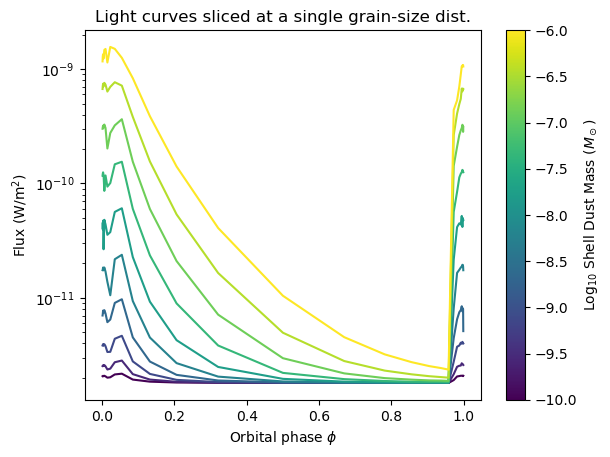

In [18]:
fig, ax = plt.subplots()

phases = xmc.sample_phases('periastron_dense', 30)

cmap_name = 'viridis'
cmap = mpl.colormaps[cmap_name]
colours = cmap(np.linspace(0, 1, len(parameter_grid['dust_mass'])))

for i in range(10):
    ax.plot(phases, grid_array[i, 5, :], c=colours[i])
ax.set(yscale='log',
       xlabel=r'Orbital phase $\phi$', ylabel=r'Flux (W/m$^2$)',
       title='Light curves sliced at a single grain-size dist.')

cmappable = ScalarMappable(Normalize(-10, -6))
cmappable.set_cmap(cmap_name)
plt.colorbar(cmappable, ax=ax, label=r'Log$_{10}$ Shell Dust Mass ($M_\odot$)')

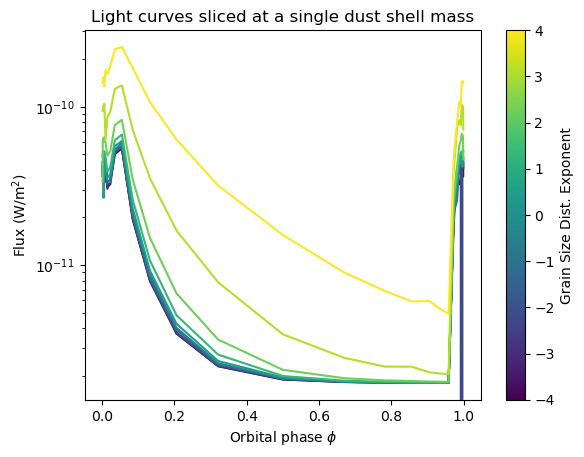

In [20]:
fig, ax = plt.subplots()

cmap_name = 'viridis'
cmap = mpl.colormaps[cmap_name]
colours = cmap(np.linspace(0, 1, len(parameter_grid['aexp'])))

for i in range(10):
    ax.plot(phases, grid_array[5, i, :], c=colours[i])
ax.set(yscale='log',
       xlabel=r'Orbital phase $\phi$', ylabel=r'Flux (W/m$^2$)',
       title='Light curves sliced at a single dust shell mass')

cmappable = ScalarMappable(Normalize(-4, 4))
cmappable.set_cmap(cmap_name)
plt.colorbar(cmappable, ax=ax, label=r'Grain Size Dist. Exponent')

In [38]:
flat_grid = np.resize(grid_array.copy(), (grid_array.shape[0] * grid_array.shape[1], grid_array.shape[2]))

log_flat_grid = np.log10(flat_grid)
log_flat_grid[log_flat_grid == -np.inf] = -32

u, s, vt = np.linalg.svd(log_flat_grid)

print(u.shape, s.shape, vt.shape, flat_grid.shape)

(100, 100) (30,) (30, 30) (100, 30)


/tmp/ipykernel_1551318/552587916.py:3: RuntimeWarning: divide by zero encountered in log10
  log_flat_grid = np.log10(flat_grid)


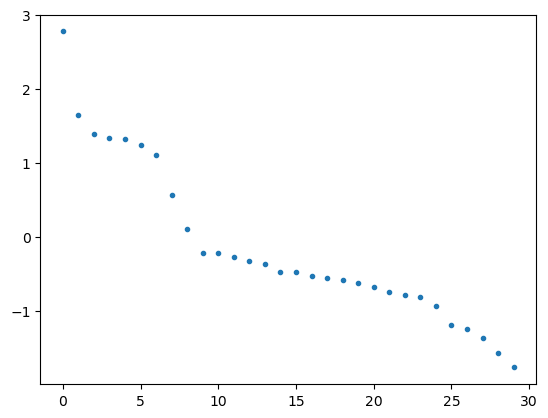

In [39]:
fig, ax = plt.subplots()
ax.plot(np.log10(s), ls='', marker='.')

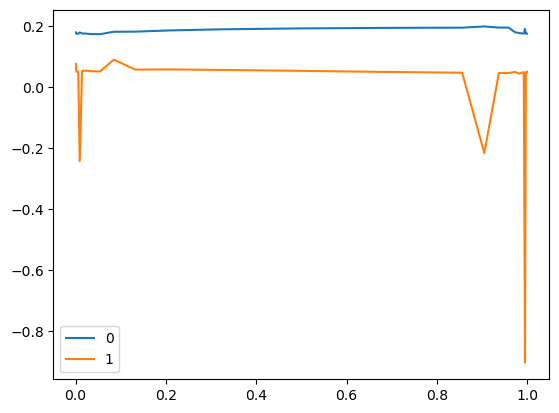

In [40]:
fig, ax = plt.subplots()

for i in range(2):
    ax.plot(phases, vt[i], label=str(i))
ax.legend()

(100, 30)


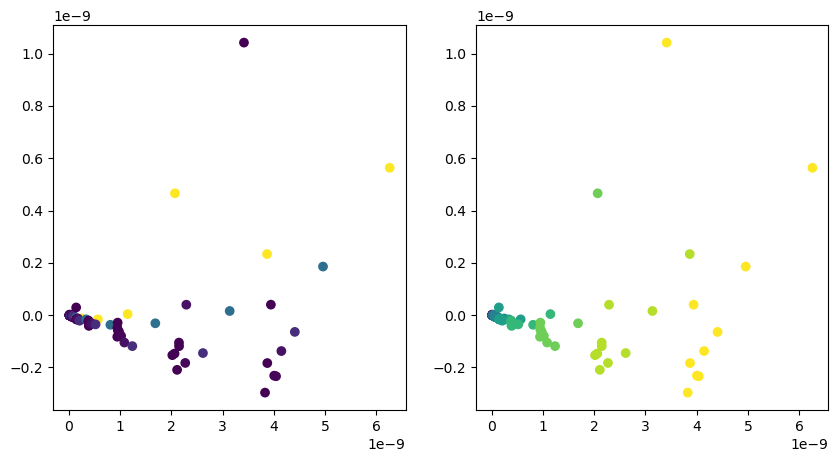

In [41]:
projections = flat_grid @ vt.T

print(projections.shape)

aa, bb = np.meshgrid(parameter_grid['dust_mass'], parameter_grid['aexp'])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.scatter(projections[:, 0], projections[:, 1], c=aa.ravel())
ax2.scatter(projections[:, 0], projections[:, 1], c=bb.ravel())